In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile
import os

path_di_drive = '/content/drive/MyDrive/content/datasetwoi.zip'

extract_path = '/content/my_data/apel'

if not os.path.exists(extract_path):
    os.makedirs(extract_path)

with zipfile.ZipFile(path_di_drive, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Selesai! File berhasil diekstrak ke:", extract_path)

Mounted at /content/drive
Selesai! File berhasil diekstrak ke: /content/my_data/apel


Found 332 files.
🚀 Training dimulai... Menghasilkan Pixel Art Apel!
Epoch 100 | Loss: 0.106666


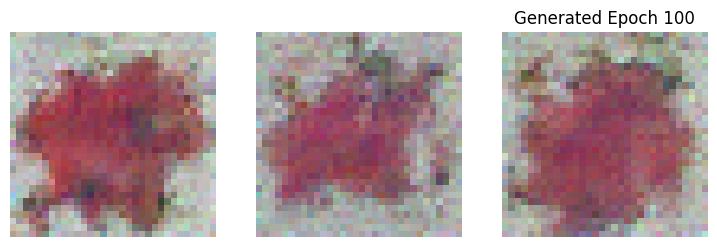

Epoch 200 | Loss: 0.077315


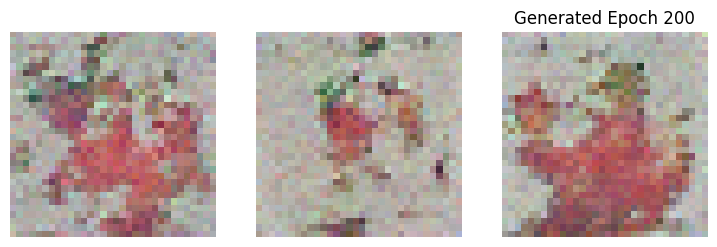

Epoch 300 | Loss: 0.067396


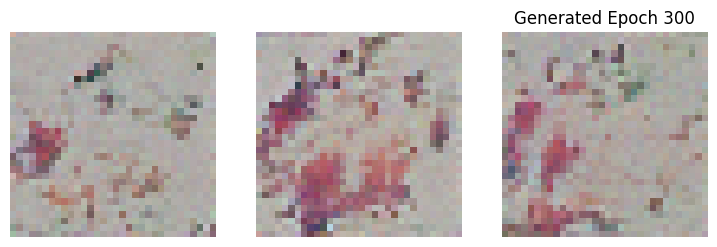

Epoch 400 | Loss: 0.056167


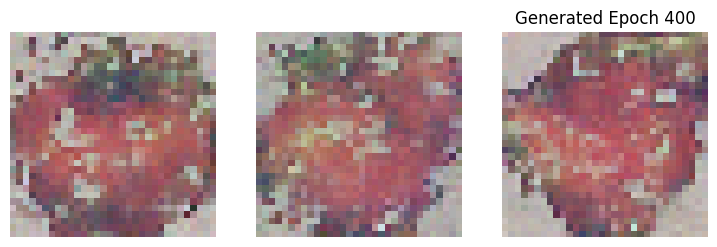

Epoch 500 | Loss: 0.043249


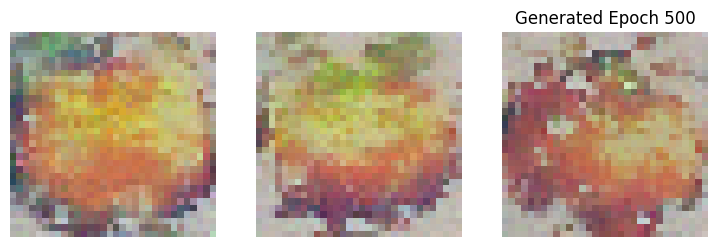

Epoch 600 | Loss: 0.048624


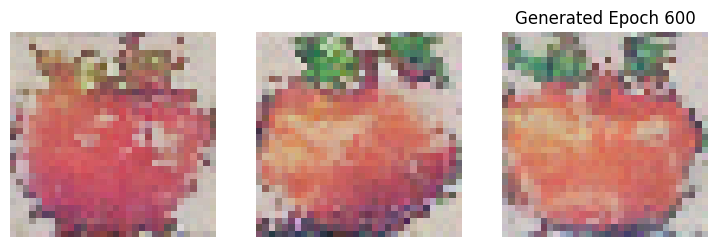

Epoch 700 | Loss: 0.049778


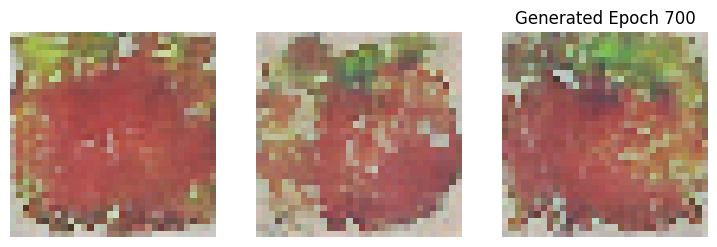

Epoch 800 | Loss: 0.048959


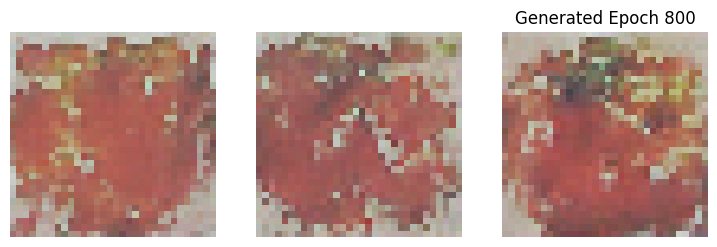

Epoch 900 | Loss: 0.057458


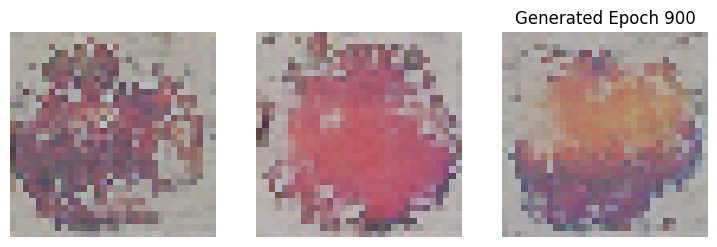

Epoch 1000 | Loss: 0.040833


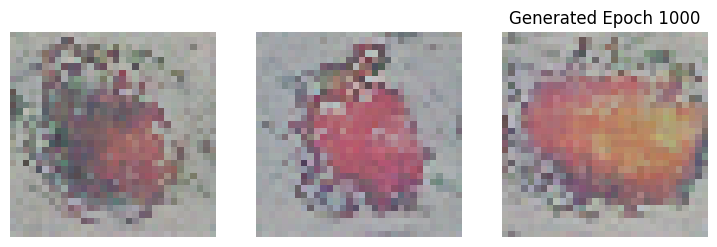

Epoch 1100 | Loss: 0.044022


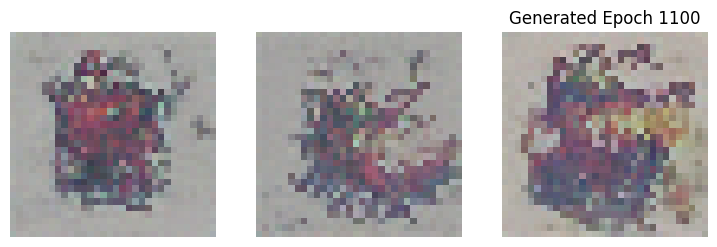

Epoch 1200 | Loss: 0.036919


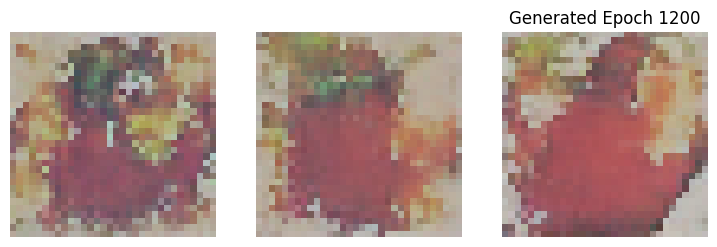

Epoch 1300 | Loss: 0.038277


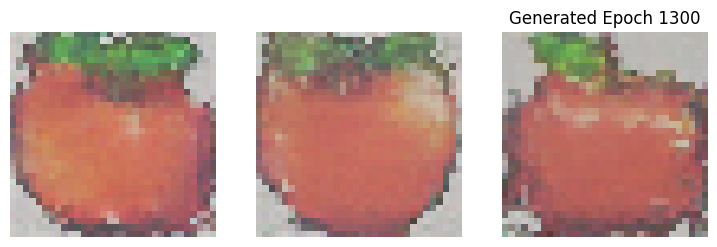

Epoch 1400 | Loss: 0.032501


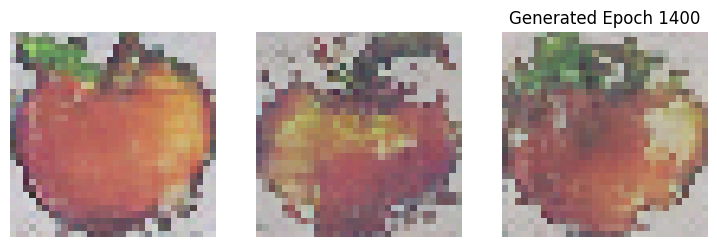

Epoch 1500 | Loss: 0.042771


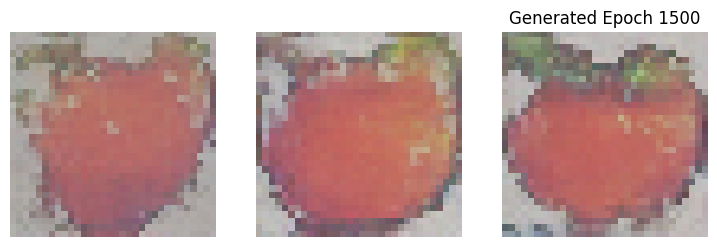

Epoch 1600 | Loss: 0.031935


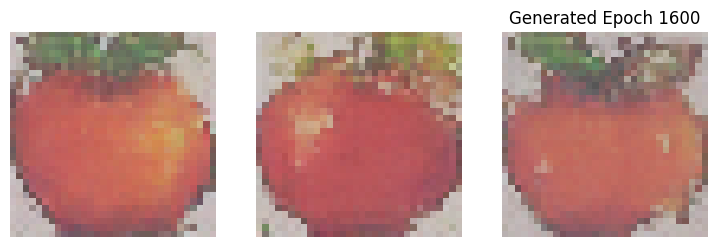

Epoch 1700 | Loss: 0.027132


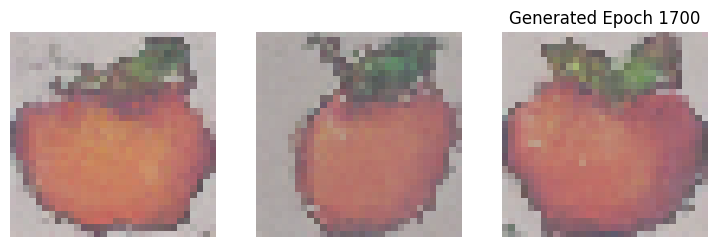

Epoch 1800 | Loss: 0.028918


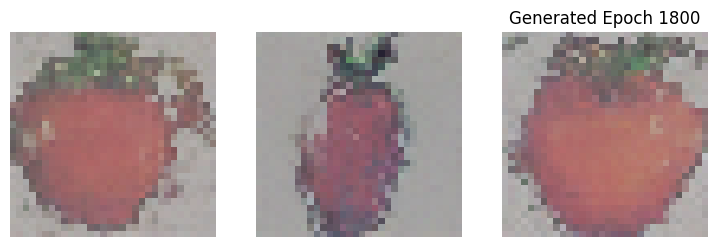

Epoch 1900 | Loss: 0.034004


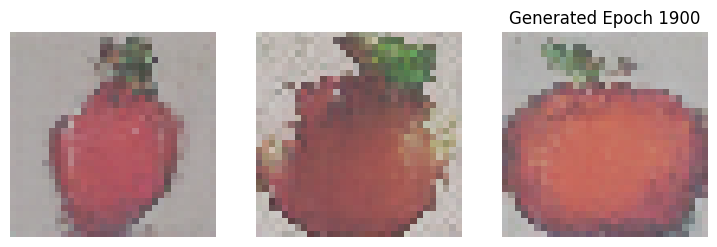

Epoch 2000 | Loss: 0.030603


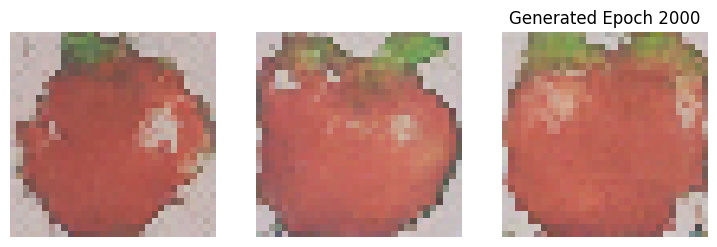

Epoch 2100 | Loss: 0.027480


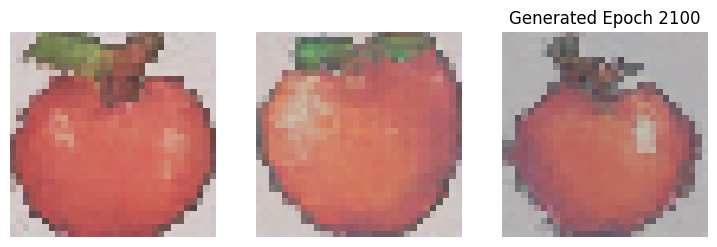

Epoch 2200 | Loss: 0.024179


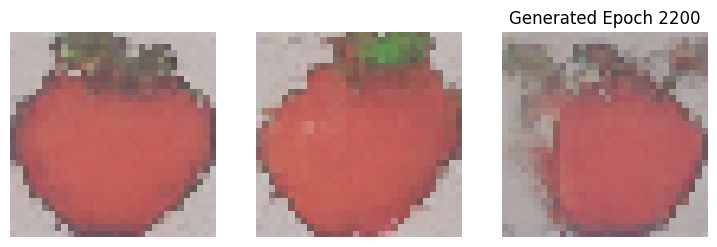

Epoch 2300 | Loss: 0.023448


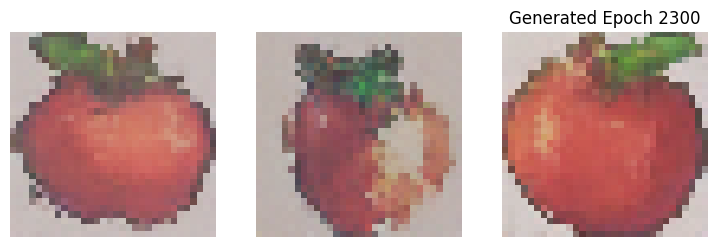

Epoch 2400 | Loss: 0.026965


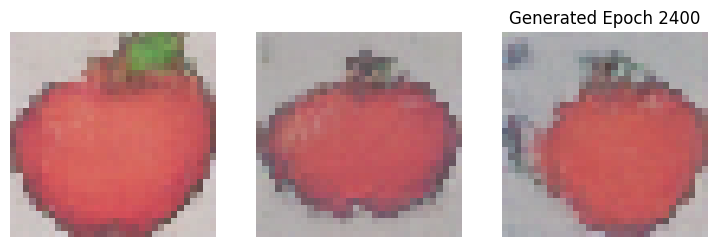

Epoch 2500 | Loss: 0.029236


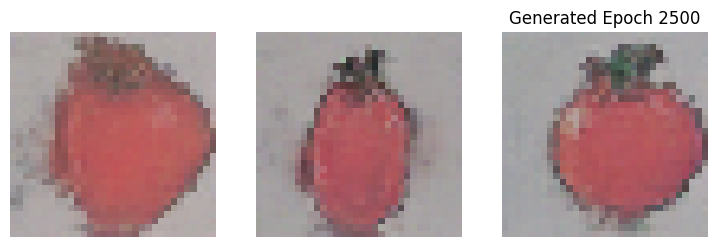

Epoch 2600 | Loss: 0.025246


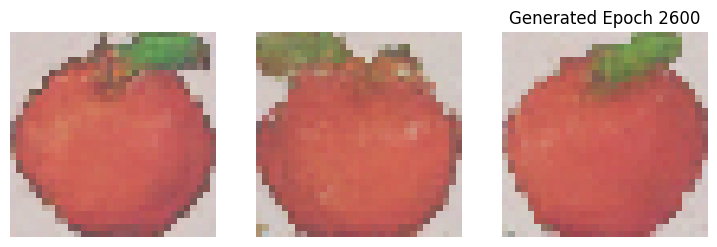

Epoch 2700 | Loss: 0.026231


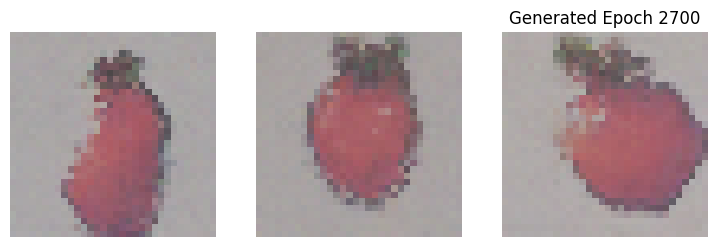

Epoch 2800 | Loss: 0.019470


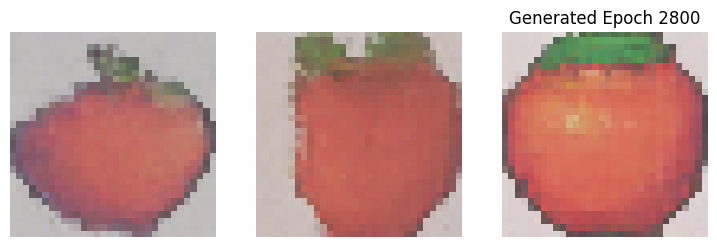

Epoch 2900 | Loss: 0.021522


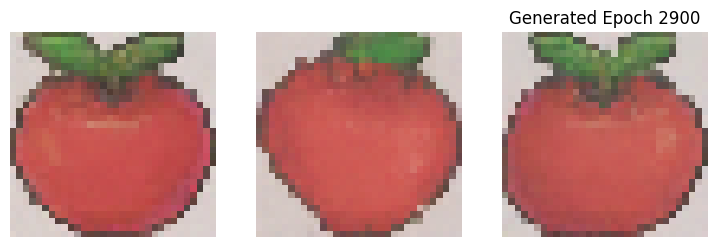

Epoch 3000 | Loss: 0.016339


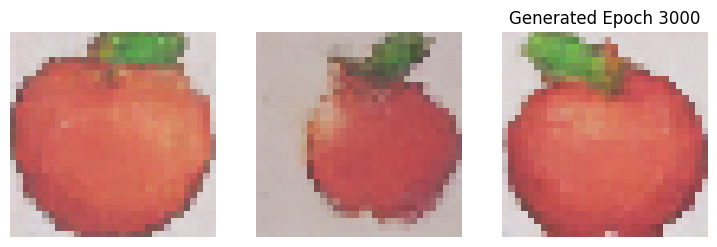

Epoch 3100 | Loss: 0.022175


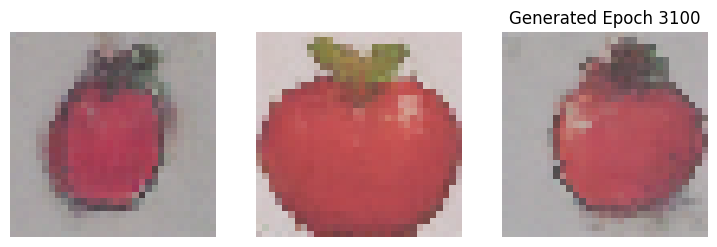

Epoch 3200 | Loss: 0.019315


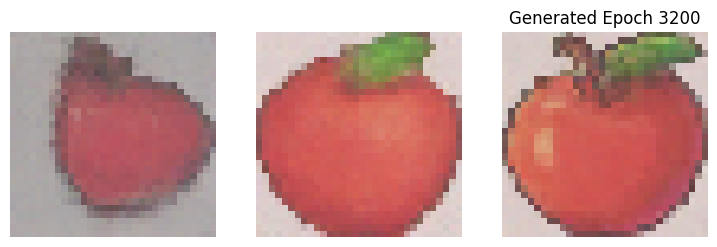

Epoch 3300 | Loss: 0.021607


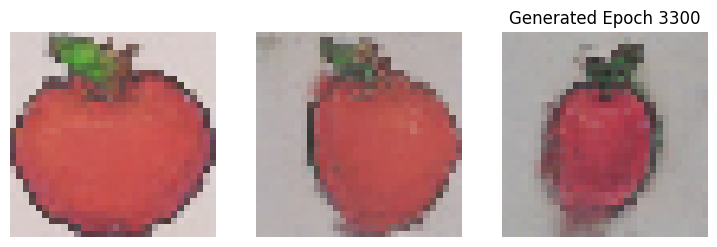

Epoch 3400 | Loss: 0.019113


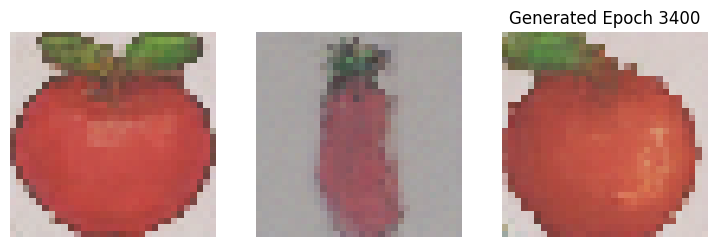

Epoch 3500 | Loss: 0.017649


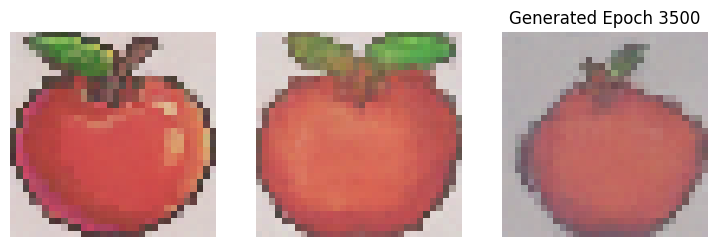

Epoch 3600 | Loss: 0.019024


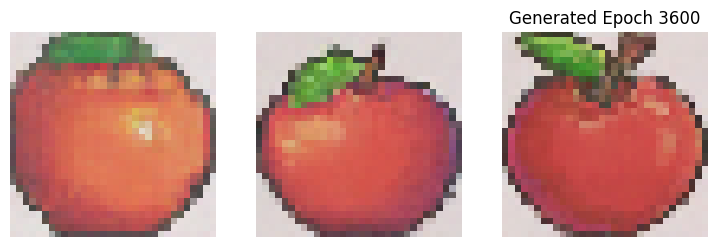

Epoch 3700 | Loss: 0.015190


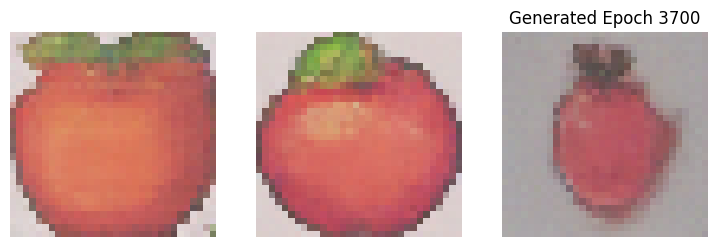

Epoch 3800 | Loss: 0.020851


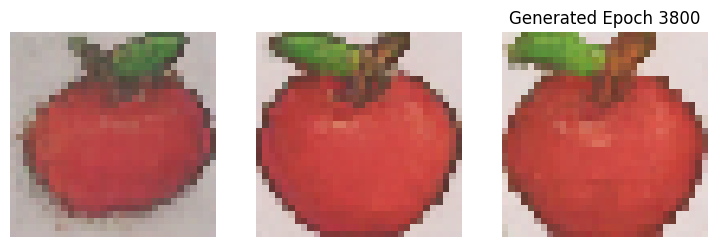

Epoch 3900 | Loss: 0.015635


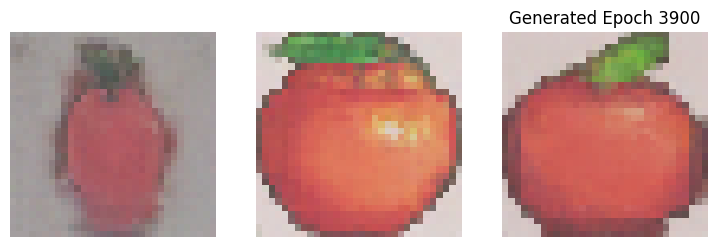

Epoch 4000 | Loss: 0.017122


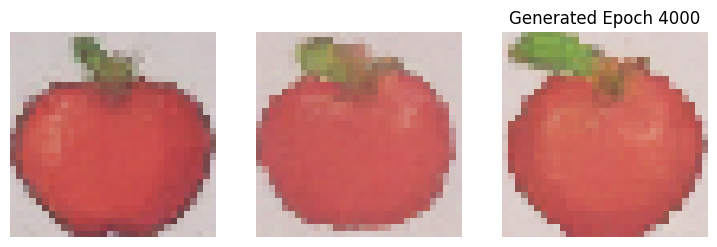

Epoch 4100 | Loss: 0.019438


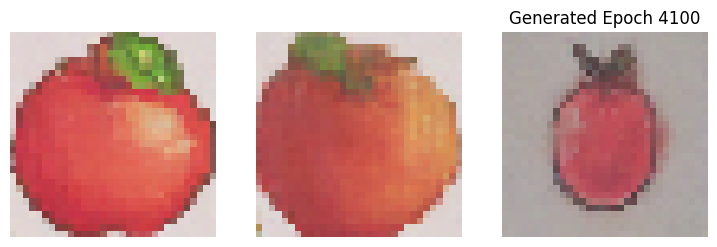

Epoch 4200 | Loss: 0.014002


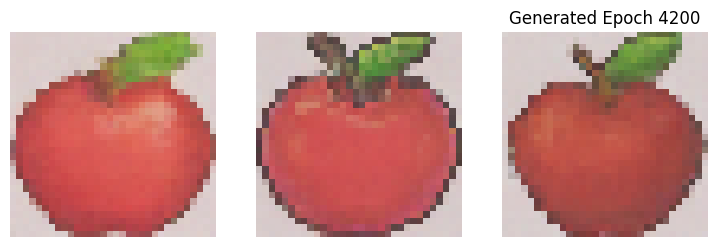

Epoch 4300 | Loss: 0.016658


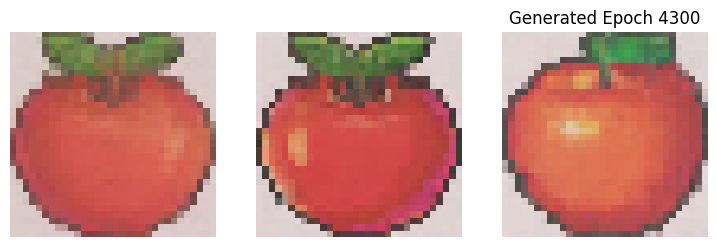

Epoch 4400 | Loss: 0.017496


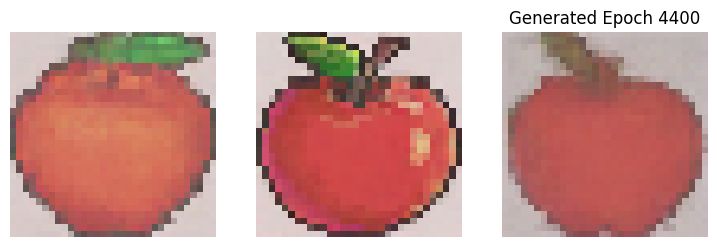

Epoch 4500 | Loss: 0.018353


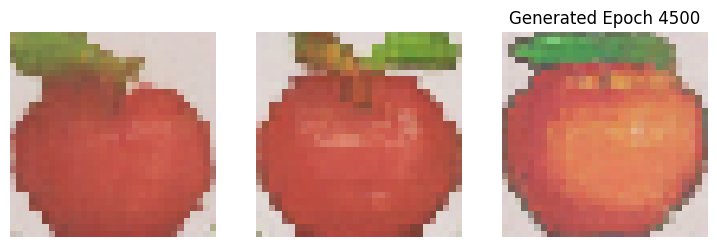

Epoch 4600 | Loss: 0.017130


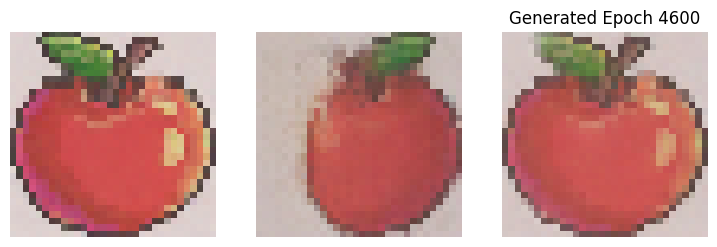

Epoch 4700 | Loss: 0.012006


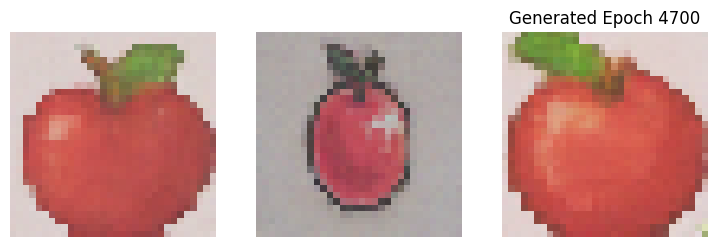

Epoch 4800 | Loss: 0.015655


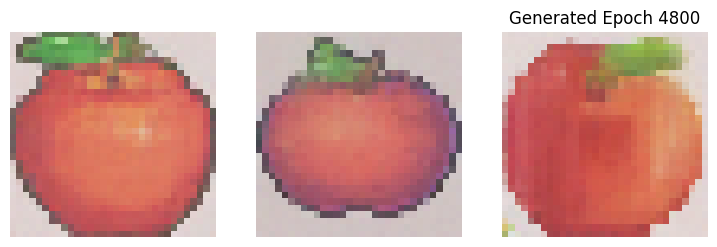

Epoch 4900 | Loss: 0.014283


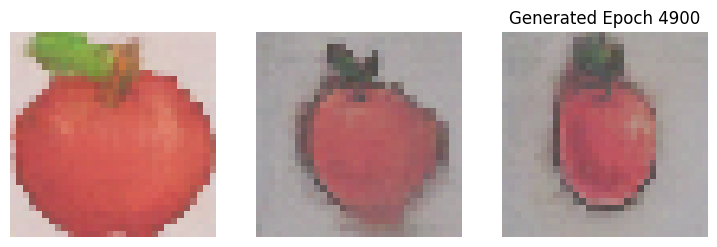

Epoch 5000 | Loss: 0.014455


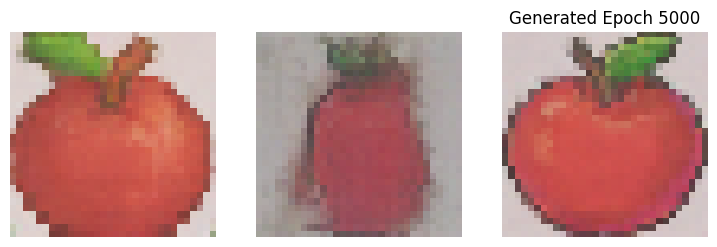

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
import os

# =====================
# 1. CONFIG
# =====================
img_size = 32
batch_size = 64
epochs = 5000
timesteps = 550
data_dir = "/content/my_data/apel"

# =====================
# 2. DATASET + SAFE AUGMENTATION
# =====================
def augment(image):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.07)
    image = tf.image.random_contrast(image, 0.93, 1.07)
    return image

if not os.path.exists(data_dir):
    print(f"⚠️ Folder {data_dir} tidak ditemukan!")

dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    label_mode=None,
    image_size=(img_size, img_size),
    batch_size=batch_size,
    shuffle=True
)

dataset = dataset.map(lambda x: (augment(x) - 127.5) / 127.5)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

# =====================
# 3. NOISE SCHEDULE
# =====================
betas = np.linspace(1e-4, 0.02, timesteps).astype('float32')
alphas = 1.0 - betas
alpha_cumprod = tf.constant(np.cumprod(alphas), dtype=tf.float32)

# =====================
# 4. MODEL ARCHITECTURE
# =====================
def residual_block(x, filters, t_emb=None):
    shortcut = x
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.GroupNormalization(groups=8)(x)
    x = layers.Activation("swish")(x)

    if t_emb is not None:
        t_w = layers.Dense(filters)(t_emb)
        t_w = layers.Reshape((1, 1, filters))(t_w)
        x = layers.Add()([x, t_w])

    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.GroupNormalization(groups=8)(x)
    x = layers.Activation("swish")(x)

    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, padding="same")(shortcut)
    return layers.Add()([x, shortcut])

def build_model():

    img_input = layers.Input(shape=(img_size, img_size, 3))
    t_input = layers.Input(shape=(1,))

    t_emb = layers.Dense(128, activation='swish')(t_input)
    t_emb = layers.Dense(128, activation='swish')(t_emb)

    # --- ENCODER ---
    c1 = residual_block(img_input, 128, t_emb)
    p1 = layers.MaxPooling2D((2, 2))(c1) # 16x16

    c2 = residual_block(p1, 256, t_emb)
    p2 = layers.MaxPooling2D((2, 2))(c2) # 8x8

    # --- BRIDGE + STABLE ATTENTION ---
    x = residual_block(p2, 512, t_emb)


    h, w, ch = x.shape[1], x.shape[2], x.shape[3]

    x_flat = layers.Reshape((h * w, ch))(x)
    x_norm = layers.LayerNormalization()(x_flat)

    attn_out = layers.MultiHeadAttention(num_heads=4, key_dim=ch)(x_norm, x_norm)
    x_flat = layers.Add()([x_flat, attn_out])

    x = layers.Reshape((h, w, ch))(x_flat)
    x = residual_block(x, 256, t_emb)

    # --- DECODER ---
    u1 = layers.UpSampling2D((2, 2))(x)
    u1 = layers.Concatenate()([u1, c2])
    u1 = residual_block(u1, 128, t_emb)

    u2 = layers.UpSampling2D((2, 2))(u1)
    u2 = layers.Concatenate()([u2, c1])
    u2 = residual_block(u2, 64, t_emb)

    out = layers.Conv2D(3, 3, padding='same')(u2)
    return Model([img_input, t_input], out)

model = build_model()
optimizer = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-5,use_ema=True,ema_momentum=0.999)

# =====================
# 5. UTILITY FUNCTIONS
# =====================
def add_noise(x, t):
    noise = tf.random.normal(shape=tf.shape(x))
    alpha_cp = tf.gather(alpha_cumprod, t)
    alpha_cp = tf.reshape(alpha_cp, (-1, 1, 1, 1))
    noisy = tf.sqrt(alpha_cp) * x + tf.sqrt(1 - alpha_cp) * noise
    return noisy, noise

def sample_images(epoch):
    n = 3
    x = tf.random.normal((n, img_size, img_size, 3))
    for t in reversed(range(timesteps)):
        t_batch = tf.ones((n, 1)) * (t / timesteps)
        pred_noise = model([x, t_batch], training=False)

        a = tf.cast(alphas[t], tf.float32)
        a_cp = tf.cast(alpha_cumprod[t], tf.float32)
        beta = tf.cast(betas[t], tf.float32)

        x_inv = (1 / tf.sqrt(a)) * (x - ((1 - a) / tf.sqrt(1 - a_cp)) * pred_noise)
        if t > 0:
            z = tf.random.normal(shape=tf.shape(x))
            x = x_inv + tf.sqrt(beta) * z
        else:
            x = x_inv
        x = tf.clip_by_value(x, -1.0, 1.0)

    x = (x + 1) / 2
    plt.figure(figsize=(9, 3))
    for i in range(n):
        plt.subplot(1, 3, i + 1)
        plt.imshow(tf.clip_by_value(x[i], 0, 1), interpolation='nearest')
        plt.axis('off')
    plt.title(f"Generated Epoch {epoch}")
    plt.show()

# =====================
# 6. TRAINING
# =====================
@tf.function
def train_step(x):
    batch = tf.shape(x)[0]
    t = tf.random.uniform((batch,), 0, timesteps, dtype=tf.int32)
    noisy, noise = add_noise(x, t)
    t_float = tf.reshape(tf.cast(t, tf.float32) / timesteps, (-1, 1))

    with tf.GradientTape() as tape:
        pred_noise = model([noisy, t_float], training=True)
        loss = tf.reduce_mean(tf.square(noise - pred_noise))

    grads = tape.gradient(loss, model.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, 1.0)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))
    return loss

def train():
    print("🚀 Training dimulai... Menghasilkan Pixel Art Apel!")
    for epoch in range(1, epochs + 1):
        loss_tracker = tf.keras.metrics.Mean()
        for real_imgs in dataset:
            loss_value = train_step(real_imgs)
            loss_tracker.update_state(loss_value)

        if epoch % 100 == 0:
            print(f"Epoch {epoch} | Loss: {loss_tracker.result():.6f}")
            sample_images(epoch)


if __name__ == "__main__":
    train()